## **Loan Approval Predictor**
#### Life cycle of a Machine Learning Project
- Understanding the problem statement
- Data collection
- Data Checks to perform
- Exploratory data analysis
- Data Pre-Processing
- Model Training
- Choose best model

### **1) Problem Statement:**
- This projects understands how customer's loan application gets approved based on several factors such as Gender, Marital status, Dependents, Education, Employment, Income, Loan amount, credit history, property area.


### **2) Data collection:**
- this dataset is sourced from kaggle
- it consists of 614 rows and 13 columns.

### **3) Importing libraries required:**

In [1]:
# importing libraries and dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:

df = pd.read_csv("C:/Users/hp/Downloads/Loan_dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [5]:
df.shape

(614, 13)

### **5) Dataset Information:**
- Loan ID
- Gender- Male / Female
-

### **5) Data Checks to perform:**
- Check Missing values
- Check Duplicates
- Check data type
- Check the number of unique values of each column
- Check statistics of data set
- Check various categories present in the different categorical column

#### **5.1) Checking for missing values:**

In [6]:
df.isna().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

##### **Missing Values**
- 13 missing in Gender
- 3 missing in Married
- 15 missing in Dependents
- 32 missing in Self_employed
- 22 missing in LoanAmount
- 50 missing in Credit_History

In [8]:
# check for data type:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [9]:
df.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [11]:
df.Credit_History.value_counts()

Credit_History
1.0    475
0.0     89
Name: count, dtype: int64

In [16]:
df.Loan_Status.value_counts()
# imbalanced dataset

Loan_Status
Y    422
N    192
Name: count, dtype: int64

In [19]:
# Loan Id not relevant for problem statement
df = df.drop(columns = ['Loan_ID'])

KeyError: "['Loan_ID'] not found in axis"

In [24]:
# imputing missing values
df.Gender.fillna(df.Gender.mode()[0], inplace = True)
df.Married.fillna(df.Married.mode()[0], inplace = True)

In [25]:
df.isna().sum()

Gender                0
Married               0
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [26]:
# Checking duplicates in the dataset
df.duplicated().sum()

np.int64(0)

**There are no duplicates in the dataset**





<Axes: xlabel='Dependents'>

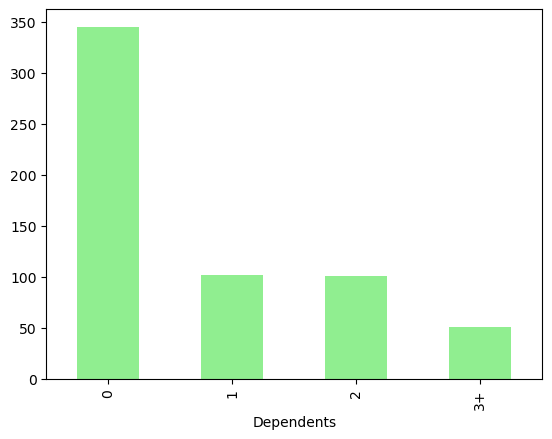

In [27]:
df.Dependents.value_counts().plot(kind = 'bar', color = 'lightgreen')

In [28]:
df.Dependents.value_counts()

Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

# imputing values proprotion wise

In [29]:
proportion = df.Dependents.value_counts(normalize = True).to_list()
missing_indices = df[df.Dependents.isna()].index
imputed_values = np.random.choice(df.Dependents.unique()[0:4], size = len(missing_indices), p = proportion)
df.loc[missing_indices, 'Dependents'] = imputed_values


In [30]:
proportion = df['Self_Employed'].value_counts(normalize = True).to_list()
missing_indices = df[df.Self_Employed.isna()].index
n = len(df['Self_Employed'].unique())
imputed_values = np.random.choice(df['Self_Employed'].unique()[0:n-1], size = len(missing_indices), p = proportion)
df.loc[missing_indices, 'Self_Employed'] = imputed_values

In [31]:
df.isna().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

 we can impute Loan Amount and credit history using Naive Bayes

<Axes: xlabel='LoanAmount', ylabel='Count'>

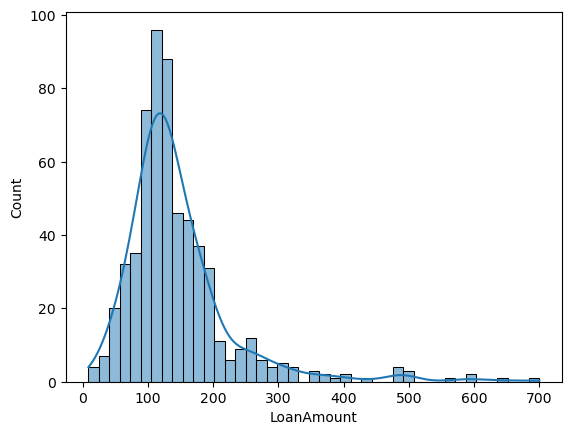

In [32]:
sns.histplot(df.LoanAmount, kde = True) # Loan Amount ko KNN impute kr skte hai

<Axes: xlabel='Loan_Amount_Term', ylabel='LoanAmount'>

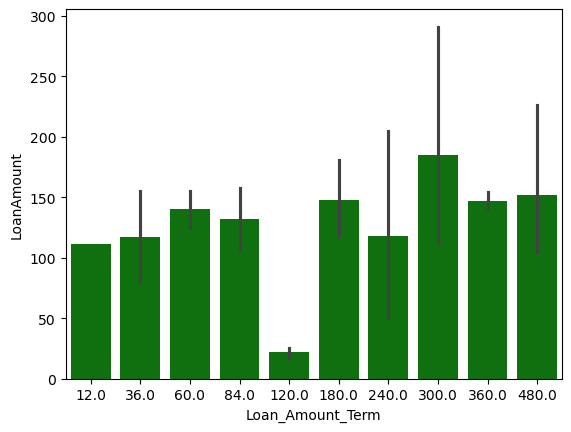

In [33]:
sns.barplot(x = df.Loan_Amount_Term, y = df.LoanAmount, color = 'g')

<Axes: xlabel='ApplicantIncome', ylabel='Count'>

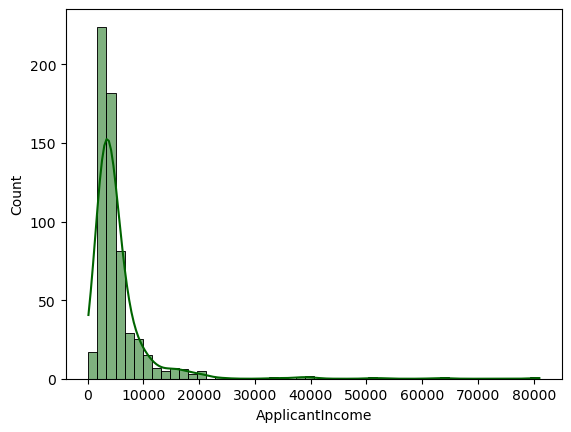

In [34]:
sns.histplot(df.ApplicantIncome, bins =50, kde = True, color = 'darkgreen')

<Axes: xlabel='CoapplicantIncome', ylabel='Count'>

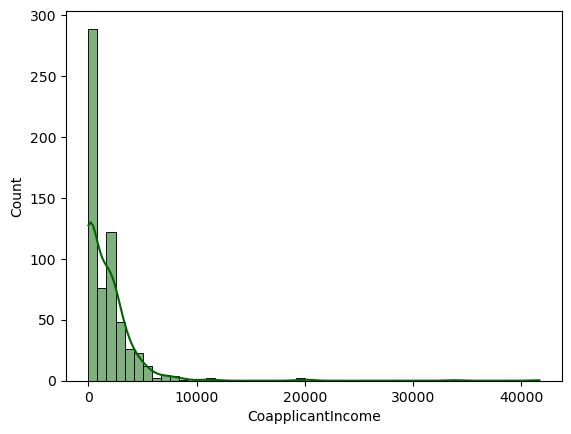

In [35]:
sns.histplot(df.CoapplicantIncome, bins =50, kde = True, color = 'darkgreen')

In [36]:
df['TotalIncome'] = df.ApplicantIncome + df.CoapplicantIncome

<Axes: xlabel='Loan_Amount_Term', ylabel='LoanAmount'>

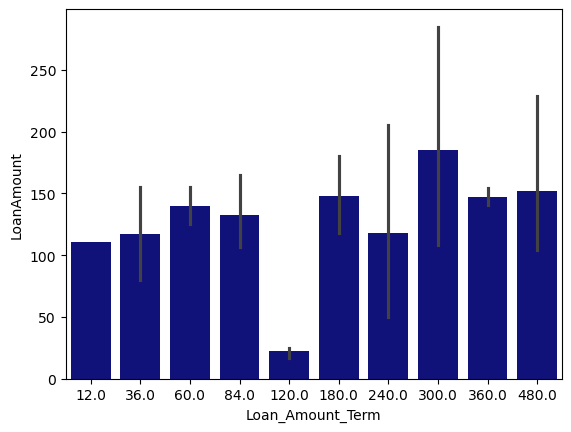

In [37]:
sns.barplot(x = df.Loan_Amount_Term, y = df.LoanAmount, color = 'darkblue')

<Axes: xlabel='Loan_Amount_Term'>

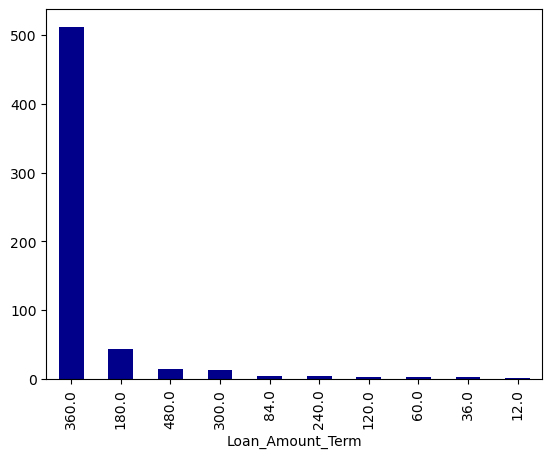

In [38]:
df.Loan_Amount_Term.value_counts().plot(kind = 'bar', color = 'darkblue')

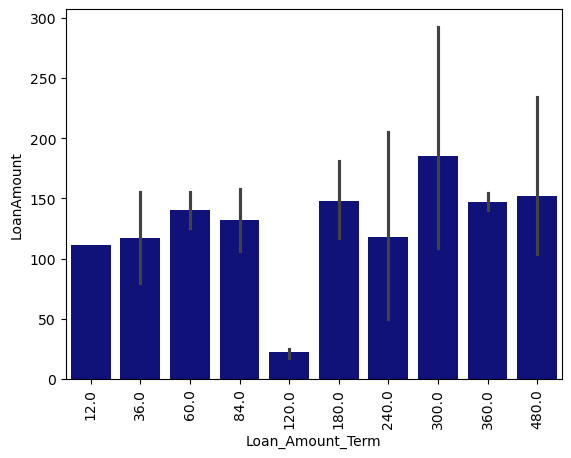

In [39]:
sns.barplot(x = df.Loan_Amount_Term, y = df.LoanAmount, color = 'darkblue')
plt.xticks(rotation = 'vertical')
plt.show()

### Lets impute Loan AMount, Loan AMount Term and Credit History using Predictive Algorithms

In [40]:
data = df.dropna()

In [41]:
data.drop(columns = ['Loan_Status'], inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_8560\3378013970.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.drop(columns = ['Loan_Status'], inplace = True)


In [42]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,6000.0
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,9613.0


<Axes: xlabel='Gender', ylabel='LoanAmount'>

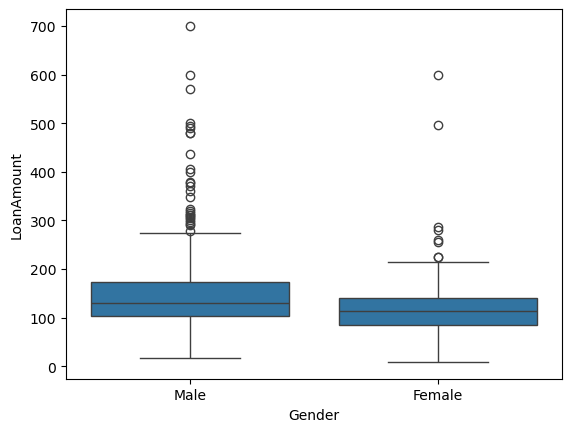

In [43]:
sns.boxplot(x = data.Gender, y= data.LoanAmount)

In [ ]:
# from scipy.stats import f_oneway
# f_stat, p_value = f_oneway(*grouped_data)
# print(f'F- statistic : {f_stat}')
# print(f'p value: {p_value}')

In [44]:
(df.shape[0]- data.shape[0])*100/df.shape[0]

13.843648208469055

### **Univariate Analysis:**


In [45]:
cat_columns = [feature for feature in data.columns if df[feature].dtype == 'object']
for col in cat_columns:
  print(f'Categories in {col} variable:', end = ' ')
  print(data[col].unique())


Categories in Gender variable: ['Male' 'Female']
Categories in Married variable: ['Yes' 'No']
Categories in Dependents variable: ['1' '0' '2' '3+']
Categories in Education variable: ['Graduate' 'Not Graduate']
Categories in Self_Employed variable: ['No' 'Yes']
Categories in Property_Area variable: ['Rural' 'Urban' 'Semiurban']


In [46]:
num_columns = [feature for feature in df.columns if df[feature].dtype != 'object']
print(f'Categorical features are: {cat_columns}')
print(f'Numerical features are: {num_columns}')

Categorical features are: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']
Numerical features are: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome']


<Axes: xlabel='Gender'>

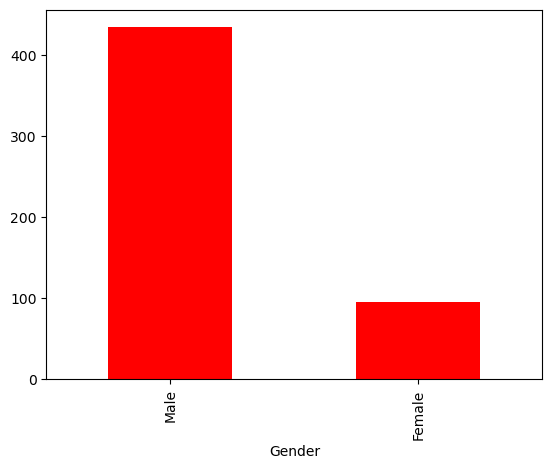

In [47]:
# 1) Gender:
data.Gender.value_counts().plot(kind = 'bar', color = 'red')

Male customers applies for Loan more than Female customers

<Axes: xlabel='LoanAmount', ylabel='Count'>

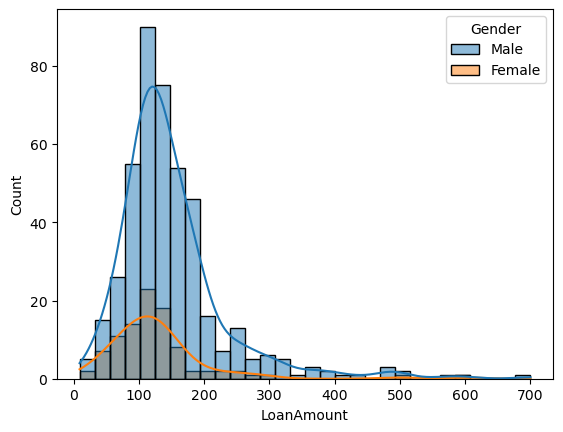

In [48]:
# Loan amount and Gender relation any :)
sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = 'Gender')

Males tend to Loan bigger amount than Females.

<Axes: xlabel='LoanAmount', ylabel='Count'>

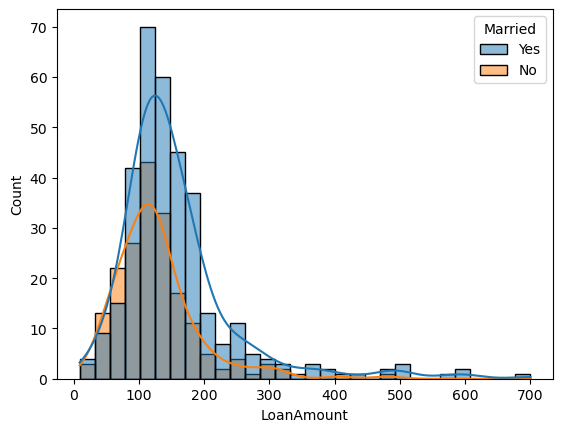

In [49]:
sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = 'Married')

Married people take higher Loan amount than Unmarried.

<Axes: xlabel='LoanAmount', ylabel='Count'>

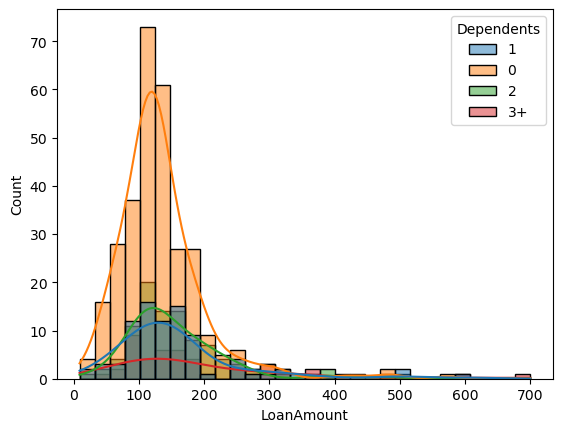

In [50]:
sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = 'Dependents')

as dependents increase, Loan amount decreases.

<Axes: xlabel='LoanAmount', ylabel='Count'>

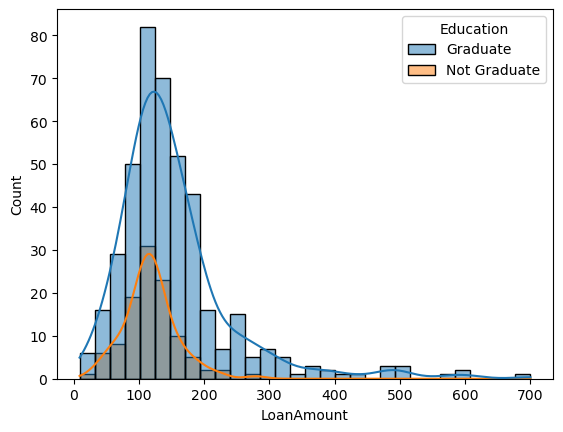

In [51]:
sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = 'Education')

<Axes: xlabel='LoanAmount', ylabel='Count'>

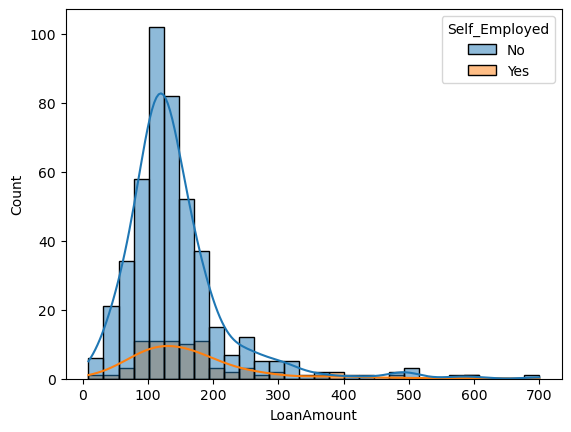

In [52]:
sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = 'Self_Employed')

<Axes: xlabel='LoanAmount', ylabel='Count'>

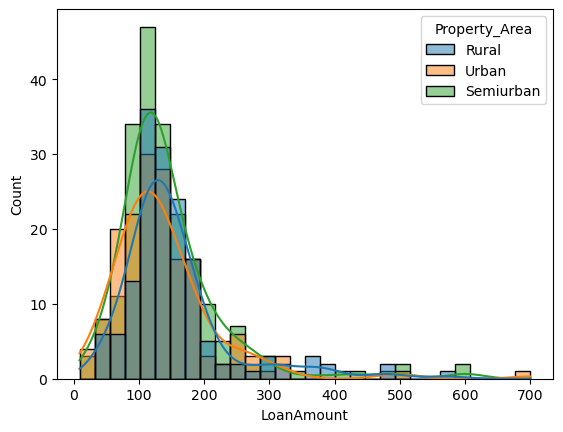

In [53]:
sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = 'Property_Area')

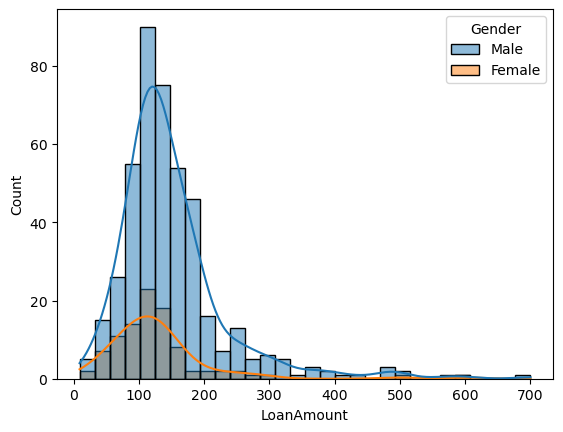

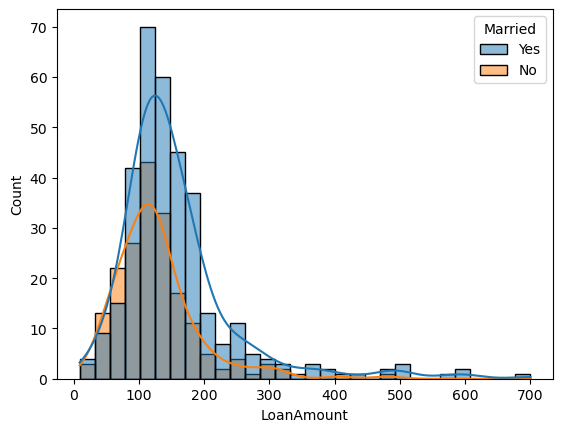

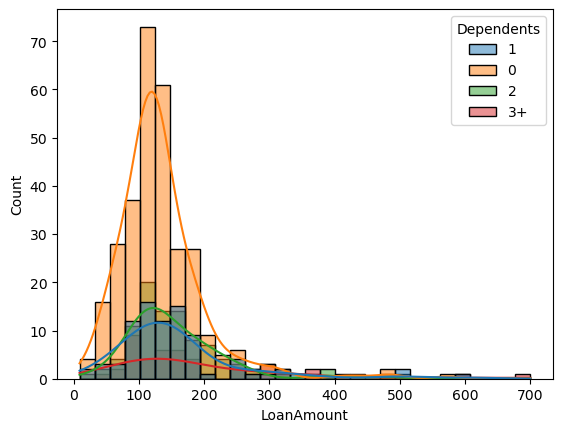

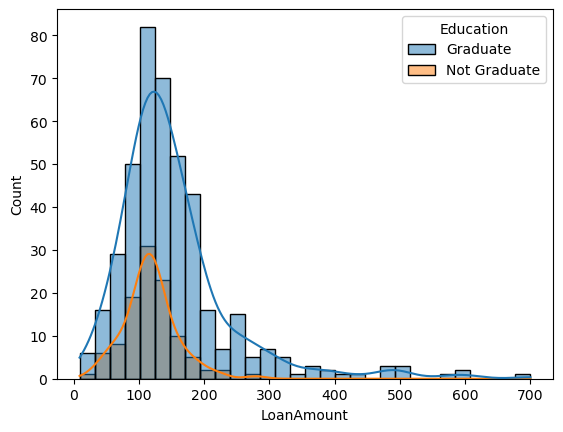

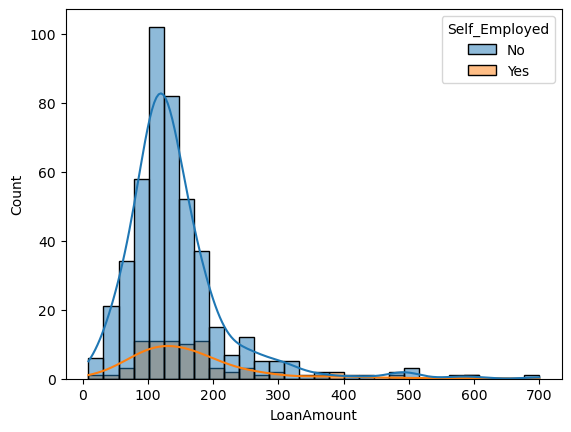

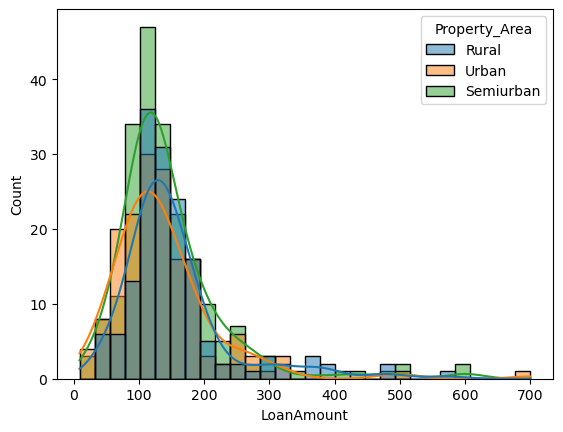

In [54]:
for col in cat_columns:
  sns.histplot(data =  data, x = 'LoanAmount', bins = 30, kde = True, hue = col)
  plt.show()

### **Interpretation**

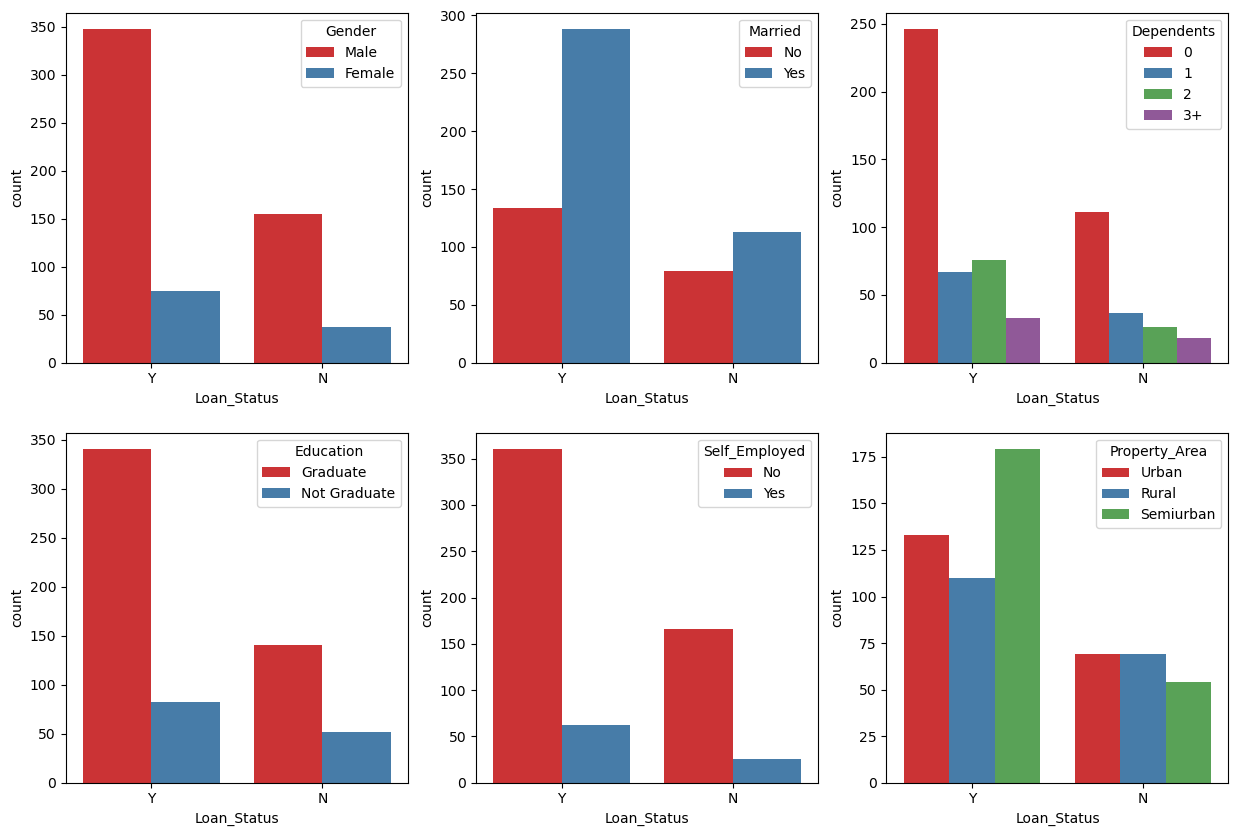

In [55]:
# cat_columns = [feature for feature in df.columns if df[feature].dtype == 'o']
fig, axes = plt.subplots(2,3,figsize = (15,10))
axes = axes.flatten()
i=0
for col in cat_columns:
  sns.countplot(x = df.Loan_Status, hue = df[col], palette='Set1', ax = axes[i])
  i+=1
# cat_columns


##### **Interpretation:**

In [56]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,6091.0
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,3000.0
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,4941.0
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,6000.0
5,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,9613.0


<Axes: >

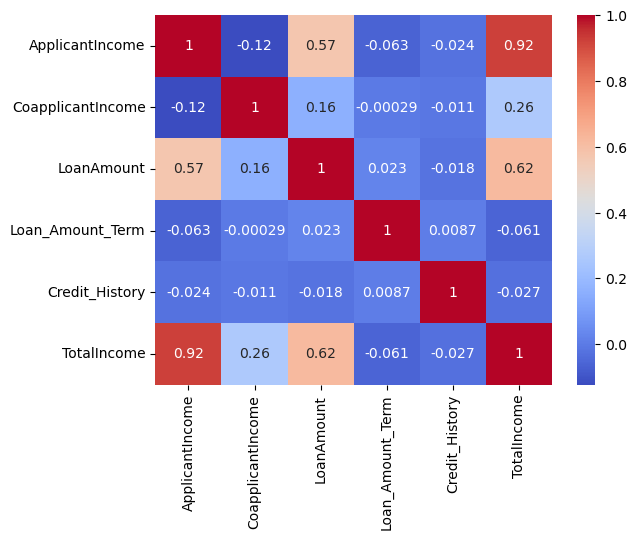

In [57]:
cov_matrix = data.corr(numeric_only = True)
sns.heatmap(cov_matrix, cmap = 'coolwarm', annot = True)

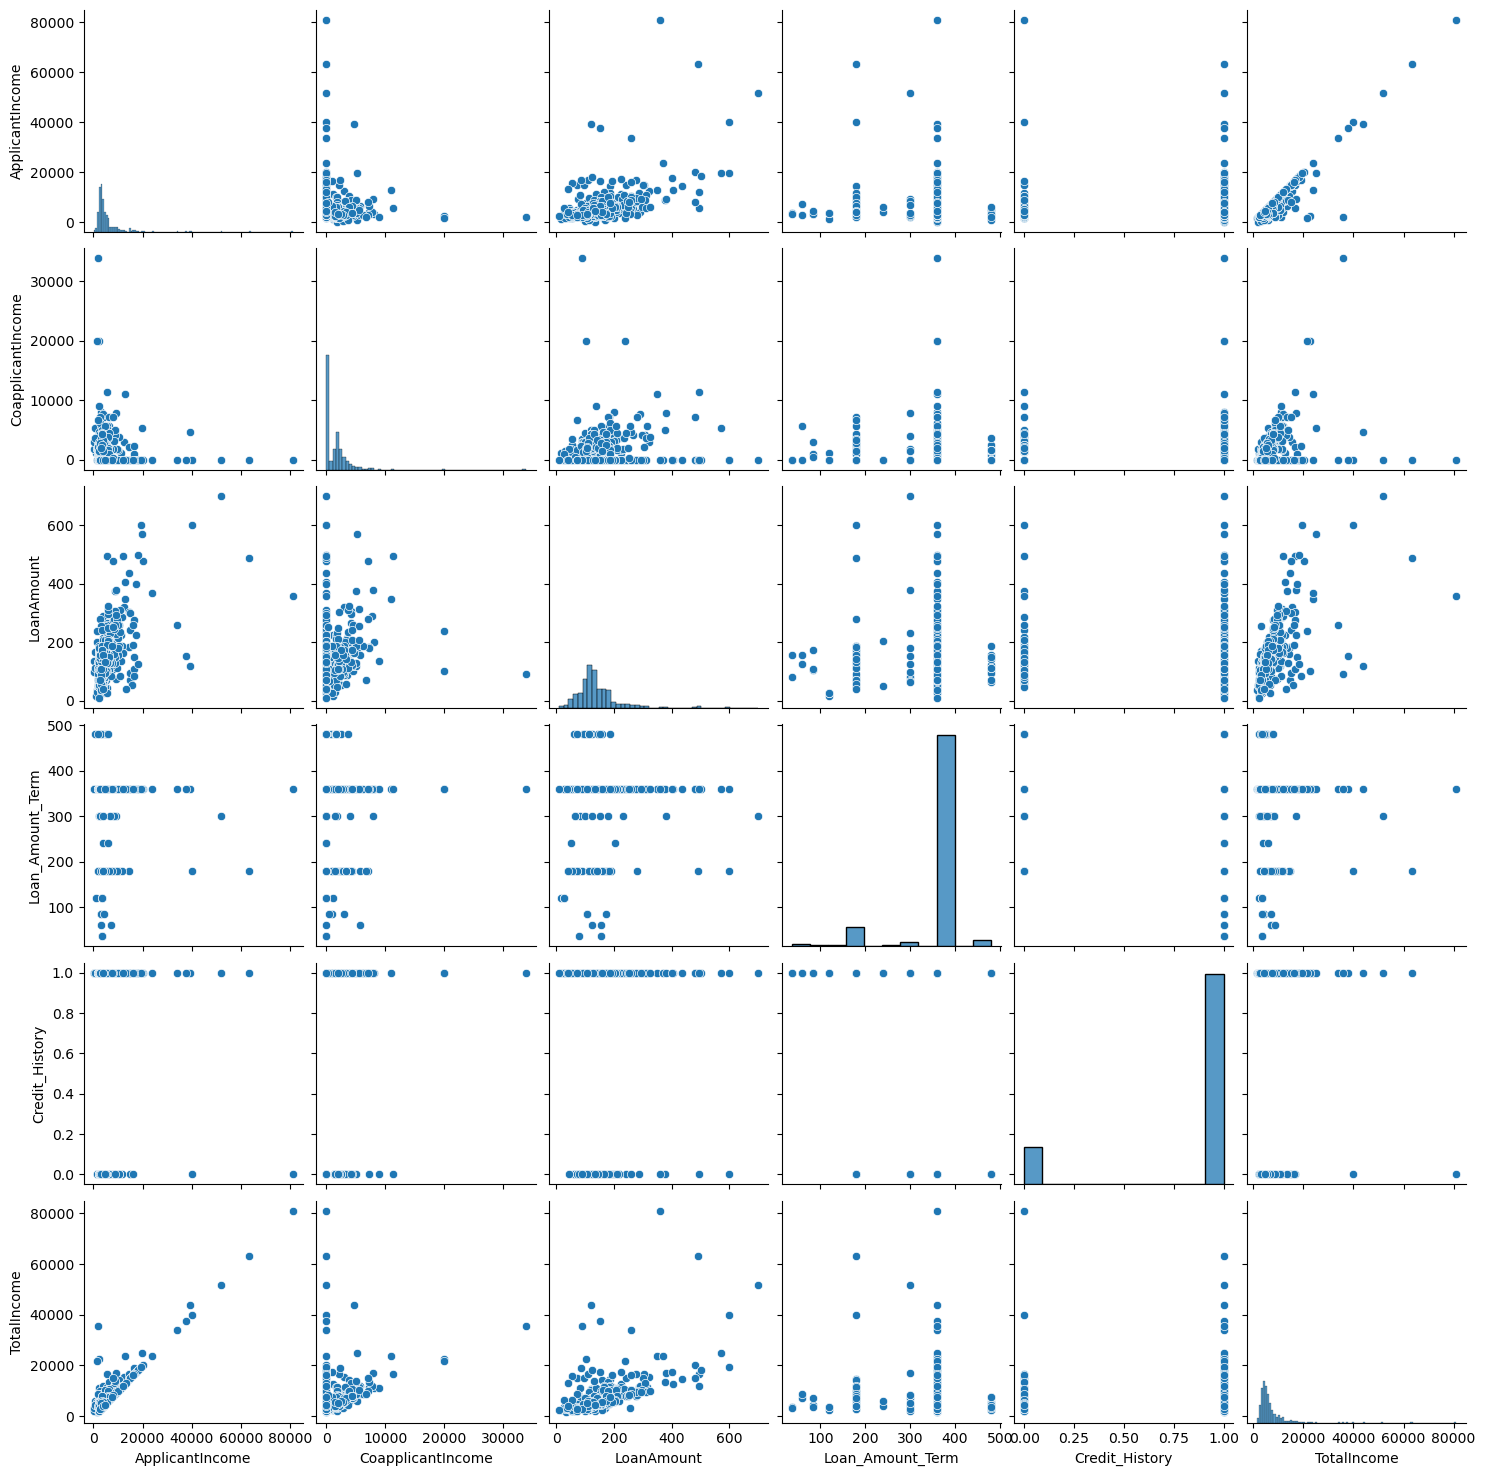

In [60]:
sns.pairplot(data)

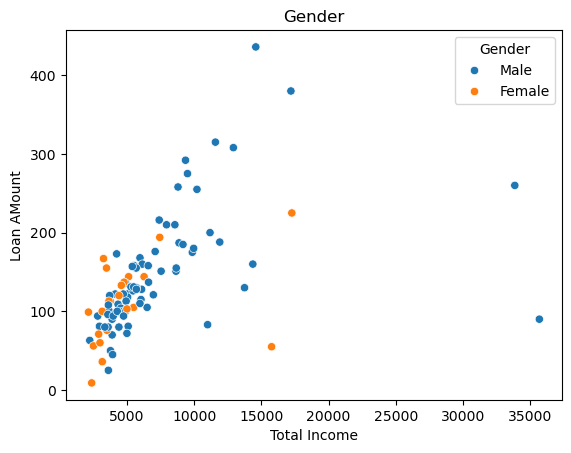

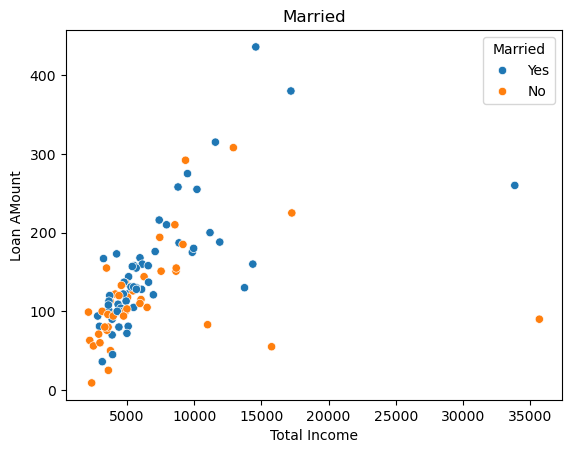

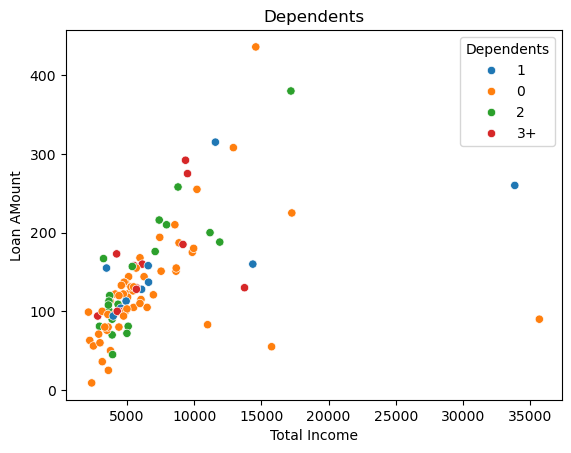

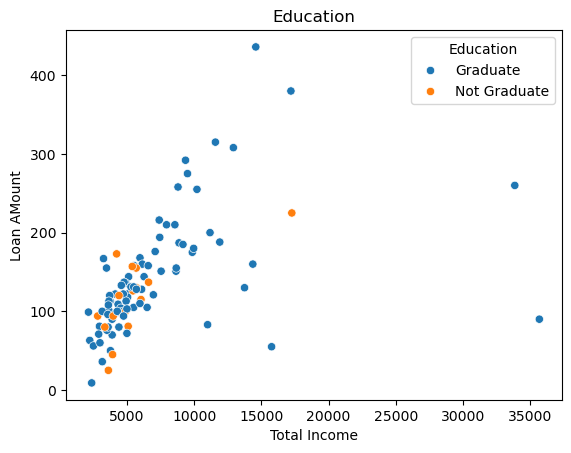

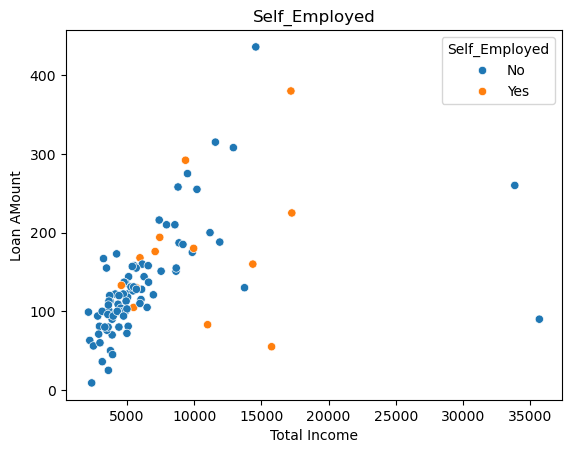

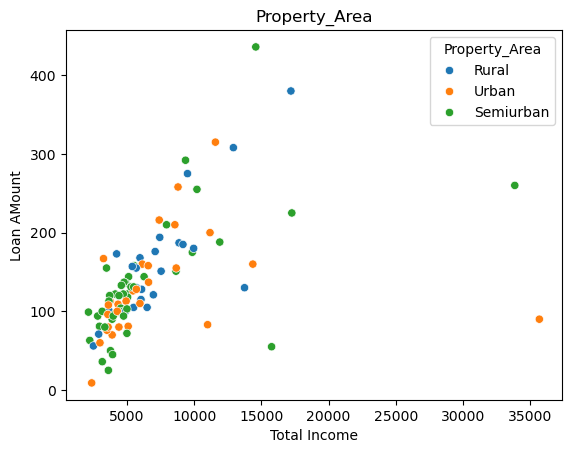

In [61]:
for col in cat_columns:
  sns.scatterplot(x = data.TotalIncome.sample(100,random_state =42), y = data.LoanAmount.sample(100, random_state = 42), hue = data[col])
  plt.xlabel('Total Income')
  plt.ylabel('Loan AMount')
  plt.title(col)
  plt.show()


In [62]:
from sklearn.impute import KNNImputer
imputer =  KNNImputer(n_neighbors=4)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             614 non-null    object 
 1   Married            614 non-null    object 
 2   Dependents         614 non-null    object 
 3   Education          614 non-null    object 
 4   Self_Employed      614 non-null    object 
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    object 
 11  Loan_Status        614 non-null    object 
 12  TotalIncome        614 non-null    float64
dtypes: float64(5), int64(1), object(7)
memory usage: 62.5+ KB


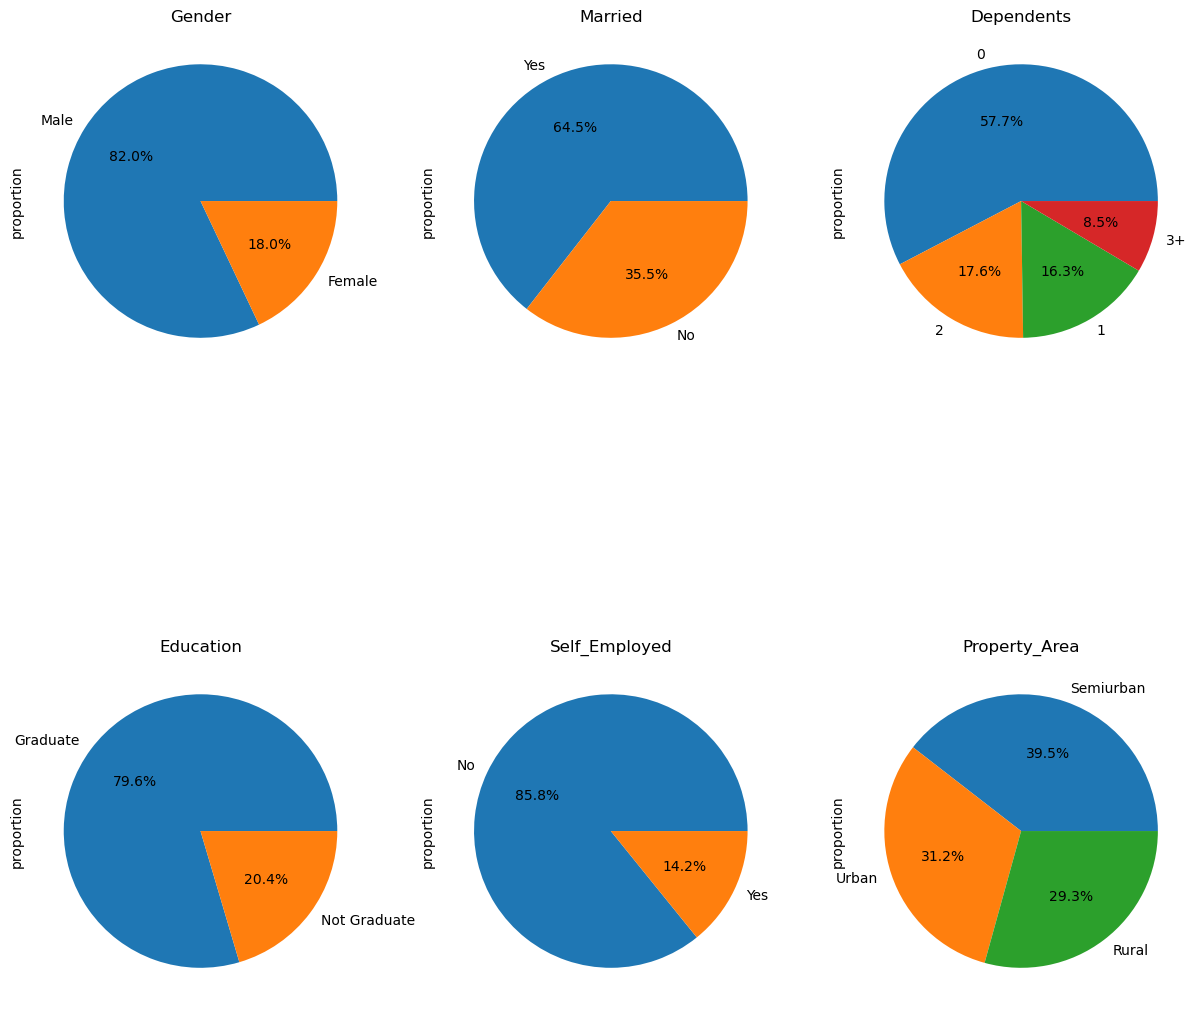

In [64]:
# Pie chart visualization of univariate data categorical
fig, axes = plt.subplots(2,3,figsize = (15,15))
axes = axes.flatten()
i = 0
for col in cat_columns:
  data[col].value_counts(normalize = True).plot(title = col,kind = 'pie', autopct = '%1.1f%%', ax = axes[i])

  i +=1




### **OUTLIERS:**
checking and removing outliers.
methods used:
-Boxplot visualization
- IQR
-Z- score


In [65]:
num_columns

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History',
 'TotalIncome']

In [66]:
from scipy.stats import zscore
outliers_income = df[abs(zscore(df.ApplicantIncome)) > 3]
outliers_income

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
126,Male,Yes,3+,Graduate,No,23803,0.0,370.0,360.0,1.0,Rural,Y,23803.0
155,Male,Yes,3+,Graduate,No,39999,0.0,600.0,180.0,0.0,Semiurban,Y,39999.0
171,Male,Yes,3+,Graduate,No,51763,0.0,700.0,300.0,1.0,Urban,Y,51763.0
183,Male,Yes,1,Graduate,No,33846,0.0,260.0,360.0,1.0,Semiurban,N,33846.0
185,Male,Yes,0,Graduate,Yes,39147,4750.0,120.0,360.0,1.0,Semiurban,Y,43897.0
333,Male,Yes,0,Graduate,No,63337,0.0,490.0,180.0,1.0,Urban,Y,63337.0
409,Male,Yes,3+,Graduate,No,81000,0.0,360.0,360.0,0.0,Rural,N,81000.0
443,Male,No,1,Graduate,No,37719,0.0,152.0,360.0,1.0,Semiurban,Y,37719.0


In [67]:
df[abs(zscore(df.Loan_Amount_Term)) > 3] # not outliers for Loan amount term

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome


In [68]:
print(df[abs(zscore(df.CoapplicantIncome)) > 3].shape)

(6, 13)


In [69]:
df[abs(zscore(df.LoanAmount)) > 3] # no outlier for Loan amount

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome


In [70]:
print(df[abs(zscore(df.TotalIncome)) > 3].shape)

(10, 13)


#### **Insights:**

In [71]:
# lets try fitting model:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
# Converting Categorical Variables:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score

In [72]:
df_try = df.dropna()
x = df_try.drop(columns = ['Loan_Status','TotalIncome'])
y = df_try.Loan_Status
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 35)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((423, 11), (423,), (106, 11), (106,))

In [73]:
num_colm = [feature for feature in x.columns if x[feature].dtype!='object']
num_colm

['ApplicantIncome',
 'CoapplicantIncome',
 'LoanAmount',
 'Loan_Amount_Term',
 'Credit_History']

In [74]:
x_train.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area'],
      dtype='object')

In [75]:
transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Credit_History','Education']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', MinMaxScaler(), num_colm)
])

In [76]:
x_train_sca = transformer.fit_transform(x_train)
x_test_sca = transformer.fit_transform(x_test)

In [77]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

In [78]:
logistic = LogisticRegression()
logistic.fit(x_train_sca, y_train)

LogisticRegression()

In [79]:
logistic.score(x_test_sca, y_test)

0.839622641509434

In [80]:
def model_report(model):
  model.fit(x_train_sca, y_train)
  y_pred = model.predict(x_test_sca)
  accuracy = round(accuracy_score(y_pred, y_test),4)

  print(f'** Reports for {model}: **')
  print('-'*35)
  print('Classification Report:')
  print(classification_report(y_pred, y_test))
  print(f'Accuracy Score: {accuracy}')
  print('='*35)

In [81]:
logistic = LogisticRegression()
dt = DecisionTreeClassifier(max_depth = 5)
rdf = RandomForestClassifier(n_estimators = 50)
svc = SVC(C = 100, kernel = 'rbf')
knn = KNeighborsClassifier(n_neighbors = 4)
model_report(logistic)
model_report(dt)
model_report(rdf)
model_report(svc)
model_report(knn)

** Reports for LogisticRegression(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.88      0.62        16
           1       0.97      0.83      0.90        90

    accuracy                           0.84       106
   macro avg       0.73      0.85      0.76       106
weighted avg       0.90      0.84      0.86       106

Accuracy Score: 0.8396
** Reports for DecisionTreeClassifier(max_depth=5): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.61      0.60        28
           1       0.86      0.85      0.85        78

    accuracy                           0.78       106
   macro avg       0.72      0.73      0.72       106
weighted avg       0.79      0.78      0.78       106

Accuracy Score: 0.783
** Reports for RandomForestClassifier(n_estimators=50): **
-----------------------------

In [84]:
import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization


In [83]:
pip install tensorflow

   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.3/351.2 MB ? eta -:--:--
   ---------------------------------------- 0.5/351.2 MB 627.5 kB/s eta 0:09:19
   ---------------------------------------- 0.5/351.2 MB 627.5 kB/s eta 0:09:19
   ---------------------------------------- 0.8/351.2 MB 728.5 kB/s eta 0:08:01
   ---------------------------------------- 1.0/351.2 MB 795.6 kB/s eta 0:07:21
   ---------------------------------------- 1.3/351.2 MB 843.8 kB/s eta 0:06:55
   ---------------------------------------- 1.3/351.2 MB 843.8 kB/s eta 0:06:55
   ---------------------------------------- 1.6/351.2 MB 871.6 kB/s eta 0:06:42
   ---------------------------------------- 1.8/351.2 MB 914.3 kB/s eta 0:06:23
   ---------------------------------------- 2.1/351.2 MB 952.0 kB/s eta 0:06

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.45.1 requires protobuf<7,>=3.20, but you have protobuf 7.35.1 which is incompatible.


   ---------------------- ----------------- 195.8/351.2 MB 8.9 MB/s eta 0:00:18
   ---------------------- ----------------- 199.5/351.2 MB 9.0 MB/s eta 0:00:17
   ----------------------- ---------------- 203.9/351.2 MB 9.1 MB/s eta 0:00:17
   ----------------------- ---------------- 207.9/351.2 MB 9.2 MB/s eta 0:00:16
   ------------------------ --------------- 211.6/351.2 MB 9.3 MB/s eta 0:00:16
   ------------------------ --------------- 215.0/351.2 MB 9.3 MB/s eta 0:00:15
   ------------------------ --------------- 216.3/351.2 MB 9.4 MB/s eta 0:00:15
   ------------------------- -------------- 220.5/351.2 MB 9.4 MB/s eta 0:00:14
   ------------------------- -------------- 223.9/351.2 MB 9.5 MB/s eta 0:00:14
   ------------------------- -------------- 227.5/351.2 MB 9.5 MB/s eta 0:00:13
   -------------------------- ------------- 230.9/351.2 MB 9.6 MB/s eta 0:00:13
   -------------------------- ------------- 234.6/351.2 MB 9.7 MB/s eta 0:00:13
   --------------------------- ---------

In [85]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim = 11))
model.add(BatchNormalization())
model.add(Dense(32, activation = 'relu'))
model.add(BatchNormalization())
# model.add(Dropout)
model.add(Dense(16, activation = 'relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))
model.summary()

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 16)                  │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,617 (14.13 KB)

 Non-trainable params: 224 (896.00 B)

In [86]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam',metrics = ['accuracy'])
history = model.fit(x_train_sca, y_train, epochs = 50, validation_data = (x_test_sca, y_test), verbose=0)

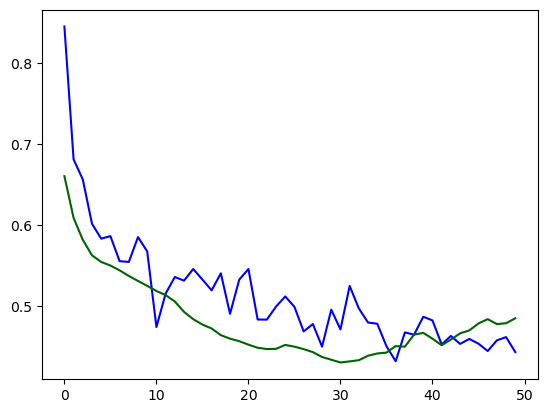

In [87]:
plt.plot(history.history['loss'],label = 'loss',color = 'blue')
plt.plot(history.history['val_loss'], label = 'val_loss', color = 'darkgreen')
plt.show()

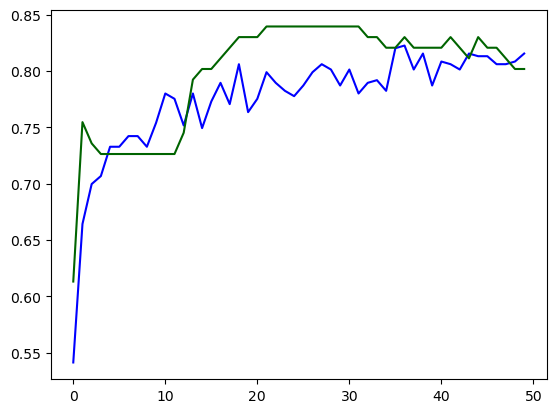

In [88]:
plt.plot(history.history['accuracy'],label = 'accuracy',color = 'blue')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy', color = 'darkgreen')
plt.show()

In [89]:
## using robust scaling to deal with outliers in applicant income and coapplicant income
from sklearn.preprocessing import RobustScaler
transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Credit_History','Education']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', MinMaxScaler(), ['Loan_Amount_Term', 'LoanAmount']),
     ('rs', RobustScaler(), ['ApplicantIncome', 'CoapplicantIncome'])
])

In [90]:
x_train_sca2 = transformer.fit_transform(x_train)
x_test_sca2 = transformer.fit_transform(x_test)

In [91]:
def model_report(model):
  model.fit(x_train_sca2, y_train)
  y_pred = model.predict(x_test_sca2)
  accuracy = round(accuracy_score(y_pred, y_test),4)

  print(f'** Reports for {model}: **')
  print('-'*35)
  print('Classification Report:')
  print(classification_report(y_pred, y_test))
  print(f'Accuracy Score: {accuracy}')
  print('='*35)

In [92]:
logistic = LogisticRegression()
dt = DecisionTreeClassifier(max_depth = 5)
rdf = RandomForestClassifier(n_estimators = 50)
svc = SVC(C = 100, kernel = 'rbf')
knn = KNeighborsClassifier(n_neighbors = 4)
model_report(logistic)
model_report(dt)
model_report(rdf)
model_report(svc)
model_report(knn)

** Reports for LogisticRegression(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.82      0.61        17
           1       0.96      0.83      0.89        89

    accuracy                           0.83       106
   macro avg       0.72      0.83      0.75       106
weighted avg       0.88      0.83      0.85       106

Accuracy Score: 0.8302
** Reports for DecisionTreeClassifier(max_depth=5): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.60      0.56        25
           1       0.87      0.83      0.85        81

    accuracy                           0.77       106
   macro avg       0.69      0.71      0.70       106
weighted avg       0.79      0.77      0.78       106

Accuracy Score: 0.7736
** Reports for RandomForestClassifier(n_estimators=50): **
----------------------------

### accuracy increased due to robust scaling.

In [93]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim = 10))
# model.add(BatchNormalization())
model.add(Dense(32, activation = 'relu'))
# model.add(BatchNormalization())
# model.add(Dropout)
model.add(Dense(16, activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))
model.summary()

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                      │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

In [94]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam',metrics = ['accuracy'])
history2 = model.fit(x_train_sca2, y_train, epochs = 40, validation_data = (x_test_sca2, y_test), verbose = 0)

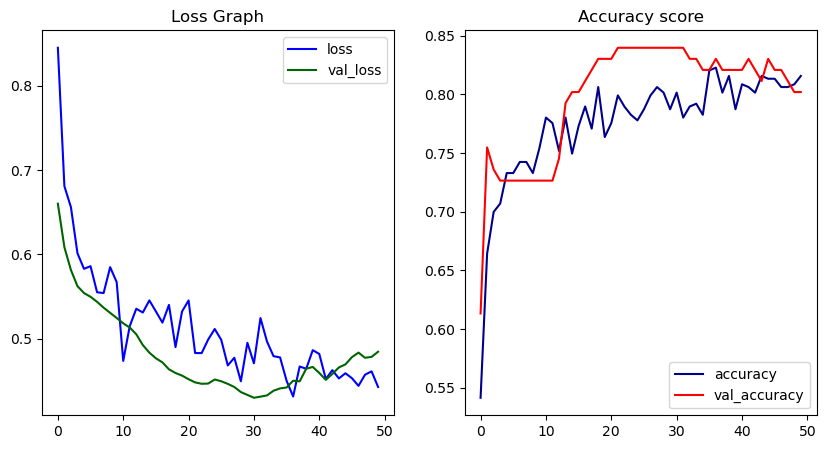

In [95]:
plt.subplots(1,2,figsize = (10,5))
plt.subplot(121)
plt.plot(history.history['loss'],label = 'loss',color = 'blue')
plt.plot(history.history['val_loss'], label = 'val_loss', color = 'darkgreen')
plt.title('Loss Graph')
plt.legend()

plt.subplot(122)
plt.plot(history.history['accuracy'],label = 'accuracy',color = 'darkblue')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy', color = 'red')
plt.title('Accuracy score')
plt.legend()
plt.show()

In [96]:
# now let's keep total income and remove applicant and co applicant income.
df_try = df.dropna()
x = df_try.drop(columns = ['Loan_Status','ApplicantIncome', 'CoapplicantIncome'])
y = df_try.Loan_Status
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 35)
x_train.shape, y_train.shape, x_test.shape, y_test.shape

((423, 10), (423,), (106, 10), (106,))

In [97]:
num_colm = [feature for feature in x.columns if x[feature].dtype!='object']
num_colm

['LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'TotalIncome']

In [98]:
transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Credit_History','Education']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', MinMaxScaler(), ['Loan_Amount_Term', 'LoanAmount']),
     ('rs', RobustScaler(), ['TotalIncome'])
])

In [99]:
x_train_sca3 = transformer.fit_transform(x_train)
x_test_sca3 = transformer.fit_transform(x_test)

In [100]:
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_test = le.fit_transform(y_test)

In [101]:
#### final function, define this at the start
def model_report(model, x_train, x_test):
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = round(accuracy_score(y_pred, y_test),4)

  print(f'** Reports for {model}: **')
  print('-'*35)
  print('Classification Report:')
  print(classification_report(y_pred, y_test))
  print(f'Accuracy Score: {accuracy}')
  print('='*35)

In [102]:
logistic = LogisticRegression()
dt = DecisionTreeClassifier(max_depth = 5)
rdf = RandomForestClassifier(n_estimators = 50)
svc = SVC(C = 100, kernel = 'rbf')
knn = KNeighborsClassifier(n_neighbors = 4)
model_report(logistic, x_train_sca3, x_test_sca3)
model_report(dt, x_train_sca3, x_test_sca3)
model_report(rdf, x_train_sca3, x_test_sca3)
model_report(svc, x_train_sca3, x_test_sca3)
model_report(knn, x_train_sca3, x_test_sca3)

** Reports for LogisticRegression(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.88      0.62        16
           1       0.97      0.83      0.90        90

    accuracy                           0.84       106
   macro avg       0.73      0.85      0.76       106
weighted avg       0.90      0.84      0.86       106

Accuracy Score: 0.8396
** Reports for DecisionTreeClassifier(max_depth=5): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.73      0.63        22
           1       0.92      0.85      0.88        84

    accuracy                           0.82       106
   macro avg       0.74      0.79      0.75       106
weighted avg       0.85      0.82      0.83       106

Accuracy Score: 0.8208
** Reports for RandomForestClassifier(n_estimators=50): **
----------------------------

In [103]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim = 9))
# model.add(BatchNormalization())
model.add(Dense(32, activation = 'relu'))
# model.add(BatchNormalization())
# model.add(Dropout)
model.add(Dense(16, activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))
model.summary()

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 64)                  │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,265 (12.75 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
x_test_sca3.shape

(106, 9)

In [105]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam',metrics = ['accuracy'])
history3 = model.fit(x_train_sca3, y_train, epochs = 40, validation_data = (x_test_sca3, y_test), verbose =0)

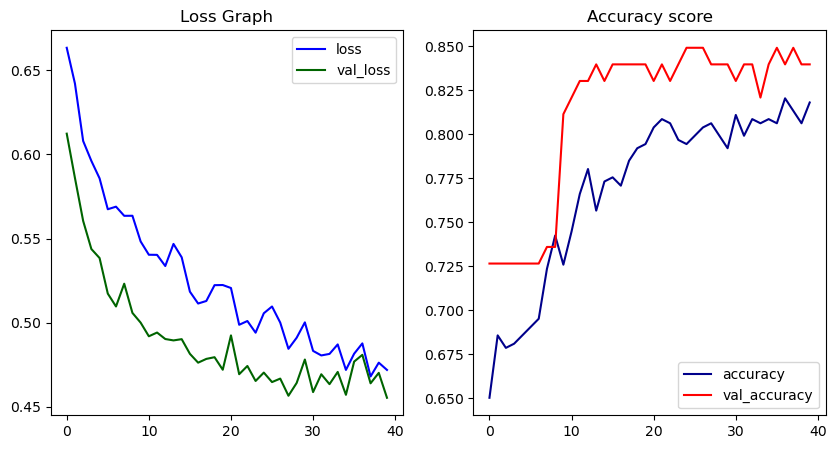

In [106]:
plt.subplots(1,2,figsize = (10,5))
plt.subplot(121)
plt.plot(history3.history['loss'],label = 'loss',color = 'blue')
plt.plot(history3.history['val_loss'], label = 'val_loss', color = 'darkgreen')
plt.title('Loss Graph')
plt.legend()

plt.subplot(122)
plt.plot(history3.history['accuracy'],label = 'accuracy',color = 'darkblue')
plt.plot(history3.history['val_accuracy'], label = 'val_accuracy', color = 'red')
plt.title('Accuracy score')
plt.legend()
plt.show()

##**showed less improvement**

### **Idea now:**
- drop total income wala column
- let applicant income and co applicant income exits
- robust scale them.
- try to see how can we remove correlation between loan amount and applicant income.

In [107]:
# lets check Variance Inflation factor for df:

from statsmodels.stats.outliers_influence import variance_inflation_factor

# X is your DataFrame with independent variables only
def calculate_vif(X):
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                       for i in range(X.shape[1])]
    return vif_data



In [108]:
x = df_try.drop(columns = cat_columns)


### trying imputation now:
- KNN imputation

In [109]:
df.isna().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
dtype: int64

##### **Loan Amount Term:**

In [110]:
missing_indices = df[df.Loan_Amount_Term.isna()].index

yf = df_try.Loan_Amount_Term
xf = df_try.drop(columns = ['Loan_Status', 'Loan_Amount_Term', 'TotalIncome'])
xf_test = df.drop(columns = ['Loan_Status', 'Loan_Amount_Term', 'TotalIncome']).loc[missing_indices]

transformer_imp = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Credit_History','Education']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', MinMaxScaler(), ['LoanAmount']),
     ('rs', RobustScaler(), ['ApplicantIncome', 'CoapplicantIncome'])
])

xf_train = transformer_imp.fit_transform(xf)
yf_train = np.log(yf)

from sklearn.neighbors import KNeighborsRegressor
impute_model = KNeighborsRegressor(n_neighbors = 4)
impute_model.fit(xf_train, yf_train)

yf_pred = impute_model.predict(transformer_imp.fit_transform(xf_test))
print('Imputed values value Loan AMount Term:\n',np.exp(yf_pred))

df.loc[missing_indices, 'Loan_Amount_Term'] = np.exp(yf_pred)

df.isna().sum()

Imputed values value Loan AMount Term:
 [360.         302.72270949 360.         302.72270949 254.55844123
 360.         360.         360.         302.72270949 360.
 302.72270949 360.         360.         343.95940519]


Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term      0
Credit_History       50
Property_Area         0
Loan_Status           0
TotalIncome           0
dtype: int64

**imputing Credit History**

In [111]:
df[df.Credit_History.isna()]

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome
16,Male,No,1,Not Graduate,No,3596,0.0,100.0,240.0,NaN,Urban,Y,3596.0
24,Male,Yes,1,Graduate,No,3717,2925.0,151.0,360.0,NaN,Semiurban,N,6642.0
30,Male,Yes,1,Graduate,No,4166,3369.0,201.0,360.0,NaN,Urban,N,7535.0
42,Male,Yes,0,Graduate,No,2400,0.0,75.0,360.0,NaN,Urban,Y,2400.0
79,Male,Yes,3+,Not Graduate,Yes,3333,2166.0,130.0,360.0,NaN,Semiurban,Y,5499.0
83,Male,Yes,0,Graduate,No,6000,2250.0,265.0,360.0,NaN,Semiurban,N,8250.0
86,Male,Yes,2,Not Graduate,No,3333,2000.0,99.0,360.0,NaN,Semiurban,Y,5333.0
95,Male,No,0,Graduate,No,6782,0.0,NaN,360.0,NaN,Urban,N,6782.0
117,Male,Yes,1,Graduate,No,2214,1398.0,85.0,360.0,NaN,Urban,Y,3612.0
125,Female,No,0,Graduate,No,3692,0.0,93.0,360.0,NaN,Rural,Y,3692.0


removing row with both Loan Amount and Credit history NaN as it will cause problem in imputation using KNN.

In [112]:
df.Credit_History.unique()

array([ 1.,  0., nan])

In [113]:
df.drop(95, inplace = True)

**imputing credit history first**

In [114]:
missing_indices = df[df.Credit_History.isna()].index

yf = df_try.Credit_History
xf = df_try.drop(columns = ['Loan_Status', 'Credit_History', 'TotalIncome'])

xf_test = df.drop(columns = ['Loan_Status', 'Credit_History', 'TotalIncome']).loc[missing_indices]

transformer_imp = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Education','Property_Area']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', MinMaxScaler(), ['Loan_Amount_Term', 'LoanAmount']),
     ('rs', RobustScaler(), ['ApplicantIncome', 'CoapplicantIncome'])
])


xf_train = transformer_imp.fit_transform(xf)
yf_train = yf

impute_model = KNeighborsClassifier(n_neighbors = 4)
impute_model.fit(xf_train, yf_train)

yf_pred = impute_model.predict(transformer_imp.fit_transform(xf_test))
print('Imputed values for Credit history:\n', yf_pred)

df.loc[missing_indices, 'Credit_History'] = yf_pred

Imputed values for Credit history:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0.
 1.]


In [115]:
df.isna().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term      0
Credit_History        0
Property_Area         0
Loan_Status           0
TotalIncome           0
dtype: int64

**imputing Loan Amount**

In [116]:
missing_indices = df[df.LoanAmount.isna()].index

yf = df_try.LoanAmount
xf = df_try.drop(columns = ['Loan_Status', 'LoanAmount', 'TotalIncome'])

xf_test = df.drop(columns = ['Loan_Status', 'LoanAmount', 'TotalIncome']).loc[missing_indices]

transformer_imp = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Education','Property_Area']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', MinMaxScaler(), ['Loan_Amount_Term']),
     ('rs', RobustScaler(), ['ApplicantIncome', 'CoapplicantIncome'])
])


xf_train = transformer_imp.fit_transform(xf)
yf_train = np.log(yf)

impute_model = KNeighborsRegressor(n_neighbors = 4)
impute_model.fit(xf_train, yf_train)

yf_pred = impute_model.predict(transformer_imp.fit_transform(xf_test))
print('Imputed values for Loan Amount:\n', np.exp(yf_pred))

df.loc[missing_indices, 'LoanAmount'] = np.exp(yf_pred)

Imputed values for Loan Amount:
 [141.65905129 140.03683677 150.15262615 123.02185616 176.36284147
 215.40703626 111.31094788 122.57984248  72.78586782 299.30872548
  72.07713291 129.76403744 143.67819139 123.45541749 226.6461401
 106.21936218 146.99808962 185.75936582 139.03024005 129.09882003
 118.76088719]


In [117]:
df.isna().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
TotalIncome          0
dtype: int64

### **now fitting models and checking accuracy scores**

<Axes: xlabel='LoanAmount', ylabel='Count'>

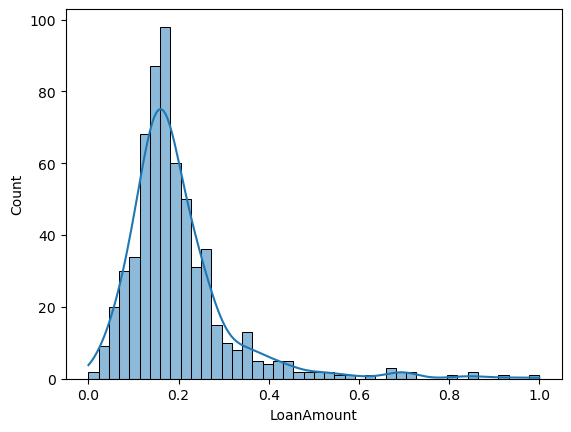

In [118]:
min_max = (df.LoanAmount - np.min(df.LoanAmount))/(np.max(df.LoanAmount) - np.min(df.LoanAmount))
sns.histplot(min_max, kde = True)

#### **requires standardization in place of normalization**

In [119]:
from sklearn.preprocessing import StandardScaler

In [120]:
transformer = ColumnTransformer(transformers=[
    ('ohe', OneHotEncoder(sparse_output = False, drop = 'first'), ['Gender','Married','Self_Employed','Credit_History','Education']),
    ('oe',OrdinalEncoder(categories=[['0','1','2','3+']]), ['Dependents']),
    ('sca', StandardScaler(), ['Loan_Amount_Term', 'LoanAmount']),
     ('rs', RobustScaler(), ['CoapplicantIncome', 'ApplicantIncome'])
])

In [121]:
x = df.drop(columns = ['Loan_Status','TotalIncome'])
y = df.Loan_Status

In [122]:
x = transformer.fit_transform(x)

In [123]:
y = le.fit_transform(y)

In [124]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 35)

In [125]:
logistic = LogisticRegression()
dt = DecisionTreeClassifier(max_depth = 5)
rdf = RandomForestClassifier(n_estimators = 50)
svc = SVC(C = 100, kernel = 'rbf')
knn = KNeighborsClassifier(n_neighbors = 4)
model_report(logistic, x_train, x_test)
model_report(dt,x_train, x_test)
model_report(rdf,x_train, x_test)
model_report(svc,x_train, x_test)
model_report(knn,x_train, x_test)

** Reports for LogisticRegression(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        11
           1       1.00      0.82      0.90       112

    accuracy                           0.84       123
   macro avg       0.68      0.91      0.71       123
weighted avg       0.94      0.84      0.87       123

Accuracy Score: 0.8374
** Reports for DecisionTreeClassifier(max_depth=5): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.81      0.55        16
           1       0.97      0.83      0.89       107

    accuracy                           0.83       123
   macro avg       0.69      0.82      0.72       123
weighted avg       0.90      0.83      0.85       123

Accuracy Score: 0.8293
** Reports for RandomForestClassifier(n_estimators=50): **
----------------------------

<Axes: xlabel='LoanAmount', ylabel='Count'>

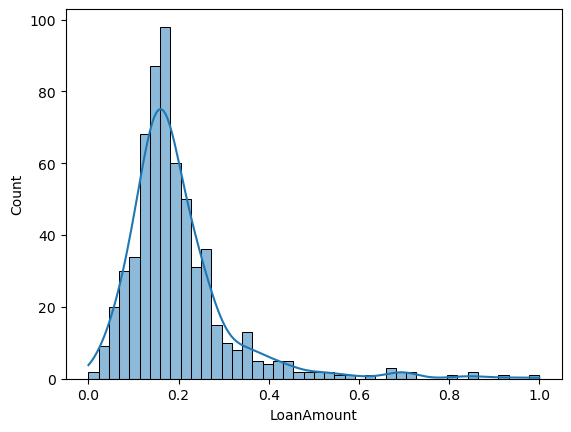

In [126]:
min_max = (df.LoanAmount - np.min(df.LoanAmount))/(np.max(df.LoanAmount) - np.min(df.LoanAmount))
sns.histplot(min_max, kde = True)

In [127]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 35)

In [128]:
x_train_res, y_train_res = smote.fit_resample(x_train, y_train)

In [129]:
print("1:", y_test.sum())
print('0:', y_test.size - y_test.sum())


1: 92
0: 31


In [130]:
#### final function, define this at the start
def model_report(model, x_train, x_test):
  model.fit(x_train, y_train_res)
  y_pred = model.predict(x_test)
  accuracy = round(accuracy_score(y_pred, y_test),4)

  print(f'** Reports for {model}: **')
  print('-'*35)
  print('Classification Report:')
  print(classification_report(y_pred, y_test))
  print(f'Accuracy Score: {accuracy}')
  print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred))
  print('='*35)

In [131]:
from sklearn.metrics import confusion_matrix
logistic = LogisticRegression()
dt = DecisionTreeClassifier(max_depth = 5)
rdf = RandomForestClassifier(n_estimators = 50)
svc = SVC(C = 100, kernel = 'rbf')
knn = KNeighborsClassifier(n_neighbors = 4)
model_report(logistic, x_train_res, x_test)
model_report(dt,x_train_res, x_test)
model_report(rdf,x_train_res, x_test)
model_report(svc,x_train_res, x_test)
model_report(knn,x_train_res, x_test)

** Reports for LogisticRegression(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        11
           1       1.00      0.82      0.90       112

    accuracy                           0.84       123
   macro avg       0.68      0.91      0.71       123
weighted avg       0.94      0.84      0.87       123

Accuracy Score: 0.8374
Confusion Matrix:
 [[11 20]
 [ 0 92]]
** Reports for DecisionTreeClassifier(max_depth=5): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.83      0.47        12
           1       0.98      0.81      0.89       111

    accuracy                           0.81       123
   macro avg       0.65      0.82      0.68       123
weighted avg       0.91      0.81      0.85       123

Accuracy Score: 0.813
Confusion Matrix:
 [[10 21]
 [ 2 90]]
** Reports f

In [132]:
x_train_res.shape

(660, 10)

C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                     │ (None, 64)                  │             704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,329 (13.00 KB)

 Trainable params: 3,329 (13.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5106 - loss: 0.7162 - val_accuracy: 0.5528 - val_loss: 0.6892
Epoch 2/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5273 - loss: 0.6949 - val_accuracy: 0.6341 - val_loss: 0.6717
Epoch 3/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5348 - loss: 0.7052 - val_accuracy: 0.6992 - val_loss: 0.6677
Epoch 4/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5409 - loss: 0.6818 - val_accuracy: 0.6911 - val_loss: 0.6675
Epoch 5/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5848 - loss: 0.6701 - val_accuracy: 0.7480 - val_loss: 0.6522
Epoch 6/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5879 - loss: 0.6625 - val_accuracy: 0.6748 - val_loss: 0.6529
Epoch 7/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6379 - loss: 0.6431 - val_accuracy: 0.7561 - val_loss: 0.6216
Epoch 8/50
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6530 - loss: 0.6349 - val_accuracy: 0.7967 - val_l

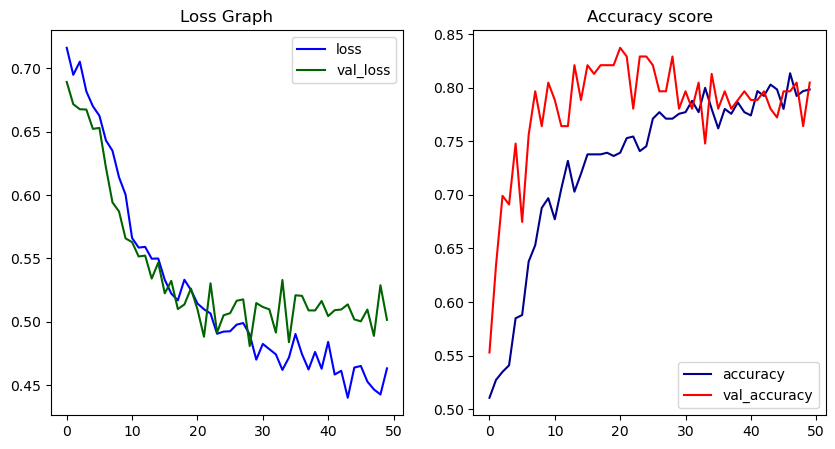

In [133]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim = 10))
# model.add(BatchNormalization())
model.add(Dense(32, activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.25))
model.add(Dense(16, activation = 'relu'))
# model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(1, activation = 'sigmoid'))
model.summary()

model.compile(loss = 'binary_crossentropy', optimizer = 'adam',metrics = ['accuracy'])
history = model.fit(x_train_res, y_train_res, epochs = 50, validation_data = (x_test, y_test), verbose =1)

plt.subplots(1,2,figsize = (10,5))
plt.subplot(121)
plt.plot(history.history['loss'],label = 'loss',color = 'blue')
plt.plot(history.history['val_loss'], label = 'val_loss', color = 'darkgreen')
plt.title('Loss Graph')
plt.legend()

plt.subplot(122)
plt.plot(history.history['accuracy'],label = 'accuracy',color = 'darkblue')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy', color = 'red')
plt.title('Accuracy score')
plt.legend()
plt.show()

### **Gaussian Naive Bayes**

In [134]:
from sklearn.naive_bayes import GaussianNB
gaussian = GaussianNB()
model_report(gaussian, x_train_res, x_test)

** Reports for GaussianNB(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.45      0.88      0.60        16
           1       0.98      0.84      0.90       107

    accuracy                           0.85       123
   macro avg       0.71      0.86      0.75       123
weighted avg       0.91      0.85      0.86       123

Accuracy Score: 0.8455
Confusion Matrix:
 [[14 17]
 [ 2 90]]


#### ek baari mein it went close to the max of random forest after hypertuning.

#### **Hypertuning Parameters**

In [135]:
from sklearn.model_selection import GridSearchCV

**Random Forest Classifier**

In [136]:
params = {
    'max_depth': [3,4,5,6,7],
    'min_samples_split': [4,5,6,7,8],
    'min_samples_leaf': [3,5,7,8],
    'n_estimators': [40,50,60,70,80]
}

In [137]:
rfc = RandomForestClassifier()
grid = GridSearchCV(rfc, param_grid = params, cv = 5, scoring = 'accuracy')
grid.fit(x_train_res, y_train_res)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'max_depth': [3, 4, 5, 6, 7],
                         'min_samples_leaf': [3, 5, 7, 8],
                         'min_samples_split': [4, 5, 6, 7, 8],
                         'n_estimators': [40, 50, 60, 70, 80]},
             scoring='accuracy')

In [138]:
print(grid.best_score_)
print(grid.best_params_)

0.7727272727272727
{'max_depth': 6, 'min_samples_leaf': 3, 'min_samples_split': 6, 'n_estimators': 60}


In [139]:
model = RandomForestClassifier(max_depth = 7, min_samples_leaf = 3, n_estimators = 70, min_samples_split = 4)
model_report(model, x_train_res, x_test)

** Reports for RandomForestClassifier(max_depth=7, min_samples_leaf=3, min_samples_split=4,
                       n_estimators=70): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.87      0.57        15
           1       0.98      0.83      0.90       108

    accuracy                           0.84       123
   macro avg       0.70      0.85      0.73       123
weighted avg       0.91      0.84      0.86       123

Accuracy Score: 0.8374
Confusion Matrix:
 [[13 18]
 [ 2 90]]


### enhanced accuracy by **3.2%**

**Support Vector Machine**

In [140]:
svc = SVC()

param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['poly'],
    'degree': [2, 3, 4],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'coef0': [0, 0.5]
}

grid_search = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')

grid_search.fit(x_train_res, y_train_res)

print("Best Parameters:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Best Parameters: {'C': 10, 'coef0': 0, 'degree': 4, 'gamma': 1, 'kernel': 'poly'}
Best Score: 0.7590909090909091


In [141]:
svc = SVC(C= 1, kernel = 'poly', gamma = 1, degree = 4, coef0 = 0)
model_report(svc, x_train_res, x_test)

** Reports for SVC(C=1, coef0=0, degree=4, gamma=1, kernel='poly'): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.46      0.48        35
           1       0.79      0.83      0.81        88

    accuracy                           0.72       123
   macro avg       0.65      0.64      0.65       123
weighted avg       0.71      0.72      0.72       123

Accuracy Score: 0.7236
Confusion Matrix:
 [[16 15]
 [19 73]]


In [142]:
svc = SVC(C= 10, kernel = 'linear', gamma = 0.1, degree = 4, coef0 = 0.5)
model_report(svc, x_train_res, x_test)

** Reports for SVC(C=10, coef0=0.5, degree=4, gamma=0.1, kernel='linear'): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        11
           1       1.00      0.82      0.90       112

    accuracy                           0.84       123
   macro avg       0.68      0.91      0.71       123
weighted avg       0.94      0.84      0.87       123

Accuracy Score: 0.8374
Confusion Matrix:
 [[11 20]
 [ 0 92]]


**it gives overall better results from random forest best model.**

Working with logistic regression models

In [146]:
logistic = LogisticRegression(penalty = 'l2')
model_report(logistic, x_train_res, x_test)

** Reports for LogisticRegression(): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        11
           1       1.00      0.82      0.90       112

    accuracy                           0.84       123
   macro avg       0.68      0.91      0.71       123
weighted avg       0.94      0.84      0.87       123

Accuracy Score: 0.8374
Confusion Matrix:
 [[11 20]
 [ 0 92]]


**Bootstrapping with logistic as base model**

In [145]:
from sklearn.ensemble import BaggingClassifier

base_model = SVC(C =10 , kernel = 'linear')

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,          # number of bootstrap samples/models
    max_samples=0.8,          # fraction of samples for each bootstrap
    bootstrap=True ,          # enable bootstrap sampling
    n_jobs = -1              # utilize all cores

)

model_report(bagging_model, x_train_res, x_test)

** Reports for BaggingClassifier(estimator=SVC(C=10, kernel='linear'), max_samples=0.8,
                  n_estimators=50, n_jobs=-1): **
-----------------------------------
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52        11
           1       1.00      0.82      0.90       112

    accuracy                           0.84       123
   macro avg       0.68      0.91      0.71       123
weighted avg       0.94      0.84      0.87       123

Accuracy Score: 0.8374
Confusion Matrix:
 [[11 20]
 [ 0 92]]
